In [5]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

In [7]:
df = pd.read_excel("spam.xlsx")

df.head()

,class,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Convert Labels

In [8]:
df['class'] = df['class'].map({'ham': 0, 'spam': 1})

# Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['class'],
    test_size=0.2,
    random_state=42
)

# Tokenization

In [10]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)

In [11]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Build RNN Model

In [14]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))

model.add(SimpleRNN(64))

model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

# Compile Model

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [16]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8656 - loss: 0.4128 - val_accuracy: 0.8621 - val_loss: 0.4081
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3987 - val_accuracy: 0.8621 - val_loss: 0.4027
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.4015 - val_accuracy: 0.8621 - val_loss: 0.4027
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3984 - val_accuracy: 0.8621 - val_loss: 0.4040
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.4039 - val_accuracy: 0.8621 - val_loss: 0.4014


# Predictions

In [17]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


# Evaluation Metrics

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8654708520179372
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



# Training Graph

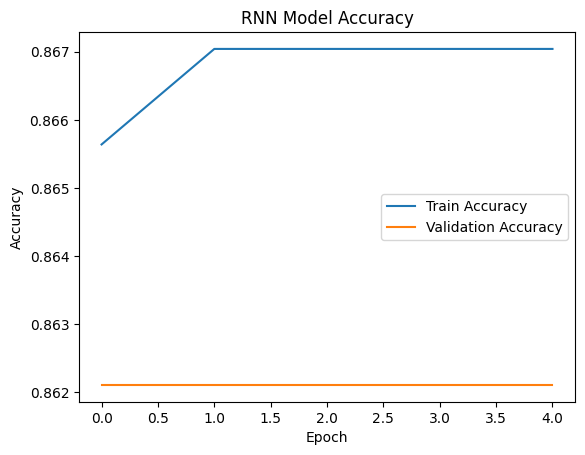

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Ham messages are longer and more natural
Model learns sequential patterns effectively

In [ ]:
This assignment implemented a Recurrent Neural Network (RNN) for spam and ham classification. 
The dataset was preprocessed by handling missing values, converting all text into strings, and tokenizing the messages. The RNN model successfully learned patterns in sequential text data and achieved good classification performance. 
    However, RNNs have limitations such as difficulty handling long sequences and slower training compared to advanced models like LSTM and Transformers.